In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import weibull_min, gamma, probplot
from scipy.optimize import minimize
import scipy.special
import csv
import os
import sys
import matplotlib.pylab as pl
from pathlib import Path

SCRIPTS_DIR = Path("../scripts")
rawDATA_DIR = Path("../data/raw")
processedDATA_DIR = Path("../data/processed")
FIG_DIR = Path("../figs")

rawDATA_DIR.mkdir(parents=True, exist_ok=True)
processedDATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(os.path.abspath("../scripts"))
from utils import fit_gamma, fit_all_weibulls

from matplotlib.backends.backend_pgf import FigureCanvasPgf
matplotlib.backend_bases.register_backend('pdf', FigureCanvasPgf)
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "font.size" : 15,
    "figure.titlesize": 15,
    "pgf.rcfonts": False    
})

# %matplotlib inline

# Plotting Weibull and Gamma distributions

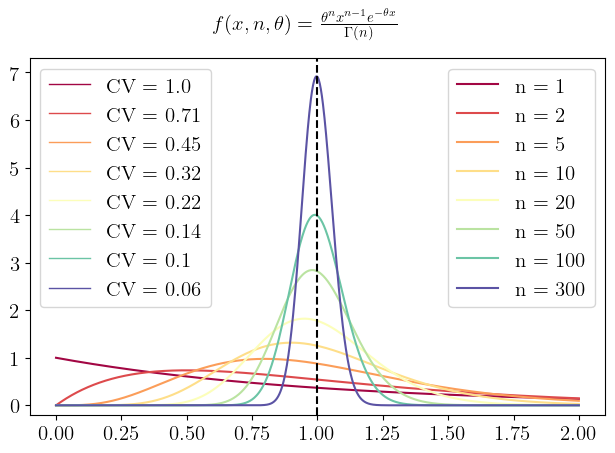

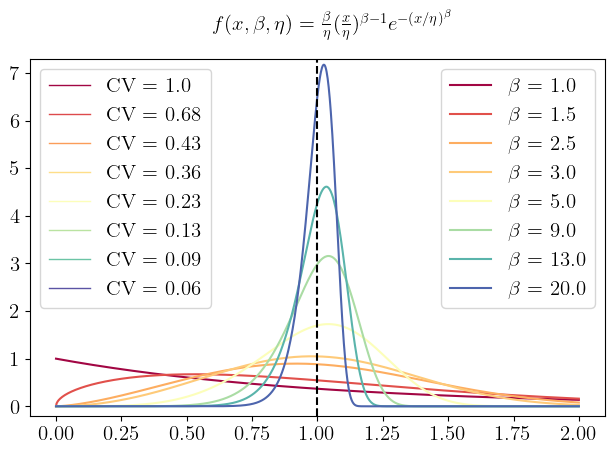

In [18]:
n_colors = 100
colors = sns.color_palette("Spectral", n_colors)

x = np.linspace(0,2,1000)

log_cv_max = np.log(gamma.std(a = 300, scale = 1/300, loc = 0))

fig = plt.figure()
gamma_shapes = np.array([1,2,5,10,20,50,100,300])
color_list = []
cv_list = []
for i,shape in enumerate(gamma_shapes):
    y = gamma.pdf(x, a = shape, scale = 1/shape, loc = 0)  
    
    cv = gamma.std(a = shape, scale = 1/shape, loc = 0) # Note how scale is set so that mean is 1
    log_cv = np.log(cv)
    norm_cv = log_cv / log_cv_max  # Normalized to [0;1]
    color_idx = int(norm_cv * (n_colors - 1))
    cv_list.append(cv)
    line_color = colors[color_idx]
    color_list.append(line_color)

    
    plt.plot(x,y, color = line_color,  label = "n = " + str(gamma_shapes[i]))
plt.vlines(1, ymin = -0.2, ymax = 7.3, linestyle = "dashed", color = "black")
plt.ylim(-0.2,7.3)
first_legend = plt.legend()

fig.add_artist(first_legend)
legend_elements = [matplotlib.lines.Line2D([0], [0], color=color_list[i], lw=1, label="CV = "+ str(np.round(cv_list[i],2))) for i in range(gamma_shapes.shape[0])]
plt.legend(handles=legend_elements, loc='upper left')

plt.text(0.6, 7.9, r"$f(x, n, \theta) = \frac{\theta^{n} x^{n -1} e^{-\theta x}}{\Gamma(n)}$") 

plt.tight_layout()
plt.savefig(FIG_DIR / "gamma_distribution.pdf")
plt.show()
plt.close()


fig = plt.figure()
weibull_shapes = np.array([1,1.5,2.5,3,5,9,13,20])
cv_list = []
for i,shape in enumerate(weibull_shapes):
    y = weibull_min.pdf(x, c = shape, scale = 1/scipy.special.gamma(1+1/shape), loc = 0) # Note how scale is set so that mean is 1
    
    cv = weibull_min.std(c = shape, scale = 1/scipy.special.gamma(1+1/shape), loc = 0)
    cv_list.append(cv)
    log_cv = np.log(cv)
    norm_cv = log_cv / log_cv_max  # Normalized to [0;1]
    color_idx = int(norm_cv * (n_colors - 1))
    line_color = colors[color_idx]
 
    plt.plot(x,y, color = line_color, label = r"$\beta$" + " = " + str(np.round(weibull_shapes[i],2)))
plt.vlines(1, ymin = -0.2, ymax = 7.3, linestyle = "dashed", color = "black")
plt.ylim(-0.2,7.3)
first_legend = plt.legend()

fig.add_artist(first_legend)
legend_elements = [matplotlib.lines.Line2D([0], [0], color=color_list[i], lw=1, label="CV = "+ str(np.round(cv_list[i],2))) for i in range(weibull_shapes.shape[0])]
plt.legend(handles=legend_elements, loc='upper left')

plt.text(0.6, 7.9, r"$f(x, \beta, \eta) = \frac{\beta}{\eta} (\frac{x}{\eta})^{\beta - 1} e^{-(x/\eta)^{\beta}}$")
plt.tight_layout()
plt.savefig(FIG_DIR / "weibull_distribution.pdf")
plt.show()
plt.close()

# A first test with two examples

In [3]:
weibull_par = np.array([0.2625,3.232,0.7581])
gamma_pars_temp = fit_gamma(weibull_par = weibull_par,
              tau_forced = True,
              save = True,
              info = "test1",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage",                           
              seed = 0) 
gamma_pars_shifted_temp = fit_gamma(weibull_par = weibull_par,
              tau_forced = False,
              save = True,
              info = "test1",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_shifted",                           
              seed = 0) 


weibull_par2 = np.array([0.2864,1.7037,0.7594])
gamma_pars_temp = fit_gamma(weibull_par = weibull_par2,
              tau_forced = True,
              save = True,
              info = "test2",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage",                           
              seed = 0) 
gamma_pars_shifted_temp = fit_gamma(weibull_par = weibull_par2,
              tau_forced = False,
              save = True,
              info = "test2",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_shifted",                                         
              seed = 0) 


weibull_par3 = np.array([0.9654,35.1806,0.])
gamma_pars_temp = fit_gamma(weibull_par = weibull_par3,
              tau_forced = True,
              save = True,
              info = "test3",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage",                           
              seed = 0) 
gamma_pars_shifted_temp = fit_gamma(weibull_par = weibull_par3,
              tau_forced = False,
              save = True,
              info = "test3",
              fig_dir = FIG_DIR,
            type_of_stage_and_shift = "per_stage_shifted",                                         
              seed = 0) 

# Fits multiples et répartition des paramètres shape obtenus : données Egg-Larva-Pupa (ou prePupa)

## Génération des fichiers de fit et de visualisation

In [4]:
gamma_pars_per_stage, gamma_pars_shifted_per_stage = fit_all_weibulls(
    input_csv = "Survey_staged",
    output = "gamma_fit_per_stage",
    raw_data_dir = rawDATA_DIR ,
    processed_data_dir = processedDATA_DIR,
    fig_dir = FIG_DIR,
    type_of_stage = "per_stage",
    seed = 0)

Beginning non shifted analysis
(0, 57)
(1, 57)
(2, 57)
(3, 57)
(4, 57)
(5, 57)
(6, 57)
(7, 57)
(8, 57)
(9, 57)
(10, 57)
(11, 57)
(12, 57)
(13, 57)
(14, 57)
(15, 57)
(16, 57)
(17, 57)
(18, 57)
(19, 57)
(20, 57)
(21, 57)
(22, 57)
(23, 57)
(24, 57)
(25, 57)
(26, 57)
(27, 57)
(28, 57)
(29, 57)
(30, 57)
(31, 57)
(32, 57)
(33, 57)
(34, 57)
(35, 57)
(36, 57)
(37, 57)
(38, 57)
(39, 57)
(40, 57)
(41, 57)
(42, 57)
(43, 57)
(44, 57)
(45, 57)
(46, 57)
(47, 57)
(48, 57)
(49, 57)
(50, 57)
(51, 57)
(52, 57)
(53, 57)
(54, 57)
(55, 57)
(56, 57)
Beginning shifted analysis
(0, 57)
(1, 57)
(2, 57)
(3, 57)
(4, 57)
(5, 57)
(6, 57)
(7, 57)
(8, 57)
(9, 57)
(10, 57)
(11, 57)
(12, 57)
(13, 57)
(14, 57)
(15, 57)
(16, 57)
(17, 57)
(18, 57)
(19, 57)
(20, 57)
(21, 57)
(22, 57)
(23, 57)
(24, 57)
(25, 57)
(26, 57)
(27, 57)
(28, 57)
(29, 57)
(30, 57)
(31, 57)
(32, 57)
(33, 57)
(34, 57)
(35, 57)
(36, 57)
(37, 57)
(38, 57)
(39, 57)
(40, 57)
(41, 57)
(42, 57)
(43, 57)
(44, 57)
(45, 57)
(46, 57)
(47, 57)
(48, 57)
(49, 57)

## Visualisation des résultats - Histogrammes

In [3]:
%matplotlib inline

In [4]:
with open(processedDATA_DIR / "gamma_fit_per_stage.npy", 'rb') as f:
    gamma_pars_per_stage = np.load(f)
with open(processedDATA_DIR / "gamma_fit_per_stage_shifted.npy", 'rb') as f:
    gamma_pars_shifted_per_stage = np.load(f)

print(np.mean(gamma_pars_per_stage[:,1]))
print(np.mean(gamma_pars_shifted_per_stage[:,1]))

print(np.max(gamma_pars_per_stage[:,1]))
print(np.max(gamma_pars_shifted_per_stage[:,1]))
print(np.min(gamma_pars_per_stage[:,1]))
print(np.min(gamma_pars_shifted_per_stage[:,1]))

significant_change_count = np.where(gamma_pars_per_stage[:,1] - gamma_pars_shifted_per_stage[:,1] > 1)[0].shape[0]
print(significant_change_count)
print(gamma_pars_per_stage.shape[0])
print(significant_change_count/gamma_pars_per_stage.shape[0])

123.32047670652915
95.98018421562388
782.2167335916554
782.2178347450695
4.477240962756284
1.8605337232301253
20
57
0.3508771929824561


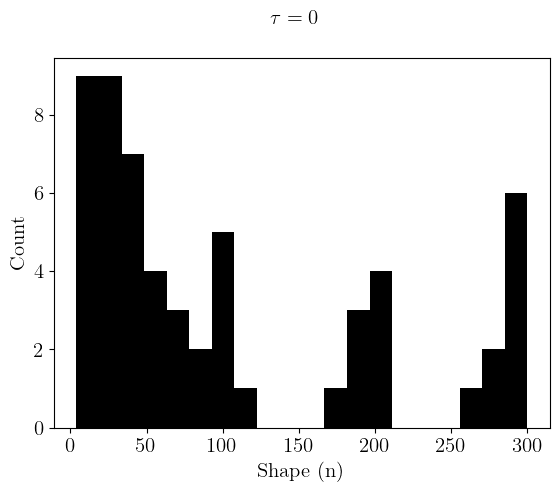

In [15]:
data = gamma_pars_per_stage[:,1].astype(int)
data = np.clip(data,0,300)
plt.close('all')
plt.figure()
plt.hist(data, bins = 20, color = "black")
plt.xlabel("Shape (n)")
plt.ylabel("Count")
plt.savefig(FIG_DIR / "histogram_not_shifted_not_clipped.pdf", bbox_inches = 'tight')
plt.suptitle(r"$\tau = 0$")
plt.show()
plt.close()

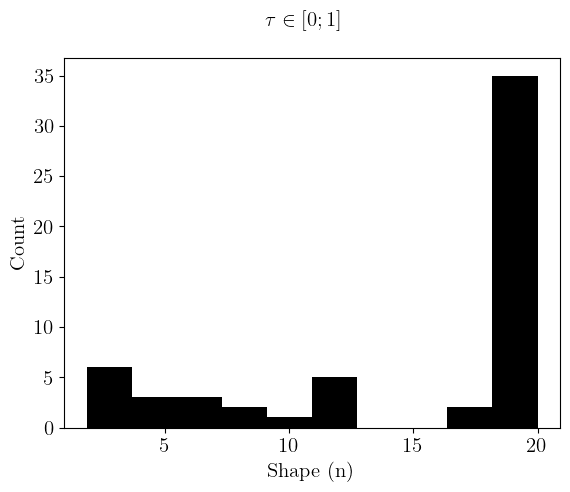

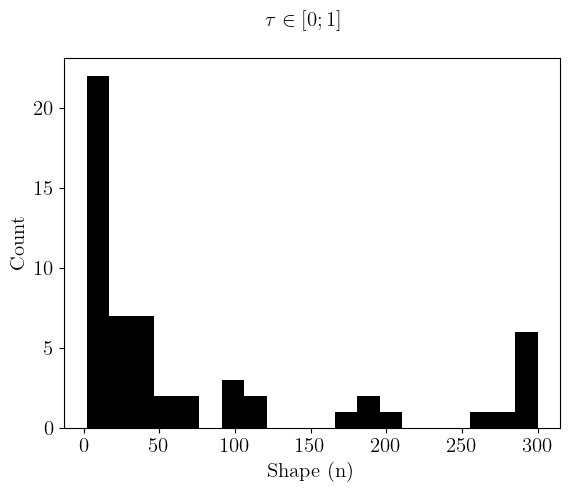

In [14]:
datasd = gamma_pars_shifted_per_stage[:,1]
datasd = np.clip(datasd, 0,20)
plt.close('all')
plt.figure()
plt.hist(datasd, bins = 10, color = "black")
plt.xlabel("Shape (n)")
plt.ylabel("Count")
plt.savefig(FIG_DIR / "histogram_shifted_clipped.pdf", bbox_inches = 'tight')
plt.suptitle(r"$\tau \in [0;1]$")
plt.show()
plt.close()


datasd = gamma_pars_shifted_per_stage[:,1]
datasd = np.clip(datasd, 0,300)
plt.figure()
plt.hist(datasd, bins = 20, color = "black")
plt.xlabel("Shape (n)")
plt.ylabel("Count")
plt.savefig(FIG_DIR / "histogram_shifted_not_clipped.pdf", bbox_inches = 'tight')
plt.suptitle(r"$\tau \in [0;1]$")
plt.show()


## Visualisation des résultats - Violinplot et effet du forçage $\tau = 0$

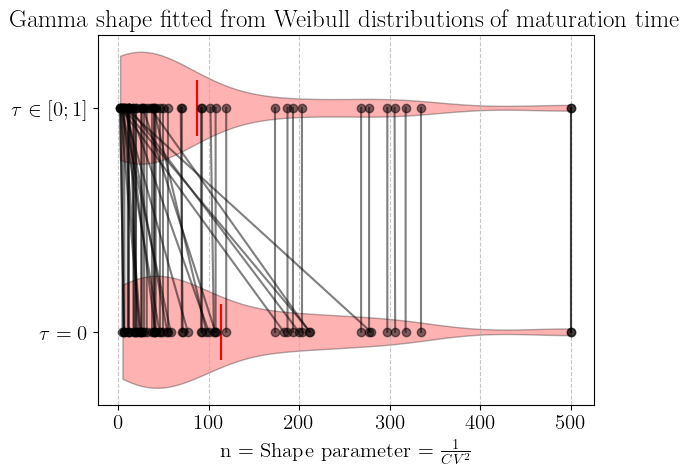

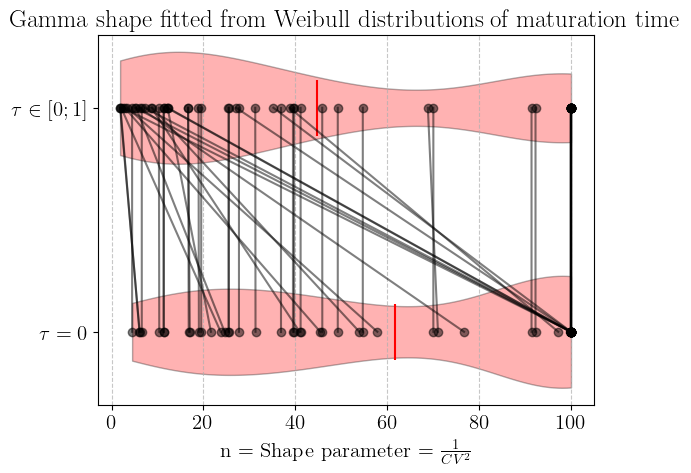

In [7]:
data1 = np.clip(gamma_pars_per_stage[:,1], 0, 500)
data2 = np.clip(gamma_pars_shifted_per_stage[:,1], 0, 500)
data = [data1, data2]


fig, ax = plt.subplots()
box = plt.violinplot(data, vert=False, positions=[1, 2], widths=0.5, showmeans=True, showmedians=False, showextrema=False)
for pc in box['bodies']:
    pc.set_facecolor('red')
    pc.set_edgecolor('black')
box['cmeans'].set_colors('red')


# Plot lines connecting paired data points
for i in range(len(data1)):
    plt.plot([data1[i], data2[i]], [1, 2],color='black', alpha=0.5, marker='o')
# Aesthetic settings
plt.yticks([1, 2])
ax.set_yticklabels([r'$\tau = 0$', r'$\tau \in [0;1]$'])
ax.set_xlabel(r'n = Shape parameter $= \frac{1}{CV^2}$')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.savefig(FIG_DIR / "n_survey_not_clipped.pdf", bbox_inches = 'tight')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()


### ZOOM ### 
data1 = np.clip(gamma_pars_per_stage[:,1], 0, 100)
data2 = np.clip(gamma_pars_shifted_per_stage[:,1], 0, 100)
data = [data1, data2]

fig, ax = plt.subplots()
box = plt.violinplot(data, vert=False, positions=[1, 2], widths=0.5, showmeans=True, showmedians=False, showextrema=False)
for pc in box['bodies']:
    pc.set_facecolor('red')
    pc.set_edgecolor('black')
box['cmeans'].set_colors('red')


# Plot lines connecting paired data points
for i in range(len(data1)):
    plt.plot([data1[i], data2[i]], [1, 2],color='black', alpha=0.5, marker='o')
# Aesthetic settings
plt.yticks([1, 2])
ax.set_yticklabels([r'$\tau = 0$', r'$\tau \in [0;1]$'])
ax.set_xlabel(r'n = Shape parameter $= \frac{1}{CV^2}$')
ax.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.savefig(FIG_DIR / "n_survey_clipped.pdf", bbox_inches = 'tight')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()

# Fits multiples et répartition des paramètres shape obtenus : données whole development

## Génération des fichiers de fit et de visualisation

In [16]:
gamma_pars_whole_dev, gamma_pars_shifted_whole_dev = fit_all_weibulls(
    input_csv = "Survey_total_juvenile",
    output = "gamma_fit_whole_dev",
    raw_data_dir = rawDATA_DIR ,
    processed_data_dir = processedDATA_DIR,
    fig_dir = FIG_DIR,
    type_of_stage = "whole_dev",
    seed = 0)

Beginning non shifted analysis
(0, 10)
(1, 10)
(2, 10)
(3, 10)
(4, 10)
(5, 10)
(6, 10)
(7, 10)
(8, 10)
(9, 10)
Beginning shifted analysis
(0, 10)
(1, 10)
(2, 10)
(3, 10)
(4, 10)
(5, 10)
(6, 10)
(7, 10)
(8, 10)
(9, 10)


In [17]:
with open(processedDATA_DIR / "gamma_fit_whole_dev.npy", 'rb') as f:
    gamma_pars_whole_dev = np.load(f)
with open(processedDATA_DIR / "gamma_fit_whole_dev_shifted.npy", 'rb') as f:
    gamma_pars_shifted_whole_dev = np.load(f)

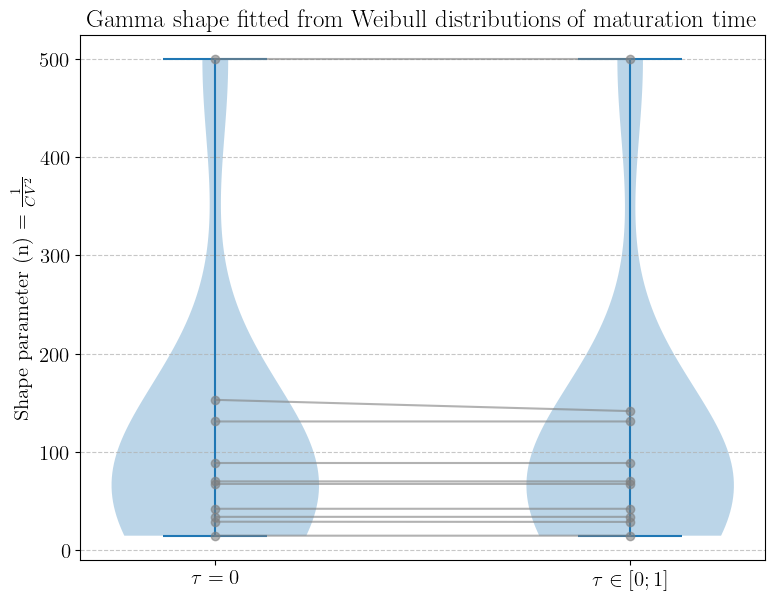

In [25]:
data1 = np.clip(gamma_pars_whole_dev[:,1], 0, 500)
data2 = np.clip(gamma_pars_shifted_whole_dev[:,1], 0, 500)

data = [data1, data2]

# Plot boxplots
fig, ax = plt.subplots(figsize=(8, 6))
box = ax.violinplot(data, positions=[1, 2], widths=0.5)

# Plot lines connecting paired data points
for i in range(len(data1)):
    ax.plot([1, 2], [data1[i], data2[i]], color='gray', alpha=0.6, marker='o')

# Aesthetic settings
ax.set_xticks([1, 2])
ax.set_xticklabels([r"$\tau = 0$", r"$\tau \in [0;1]$"])
ax.set_ylabel(r'Shape parameter (n) $= \frac{1}{CV^2}$')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(FIG_DIR / "n_survey_whole_dev.pdf", bbox_inches = 'tight')
ax.set_title('Gamma shape fitted from Weibull distributions of maturation time')
plt.show()
plt.close()

## Gamma shapes fittées quand les données par stage et sur tout le développement sont disponibles

- Ips avulsus
- Cnaphalocrocis medinalis
- Amblyesius womersleyi
- Feltiella acarisuga
- Neoseiulus californicus

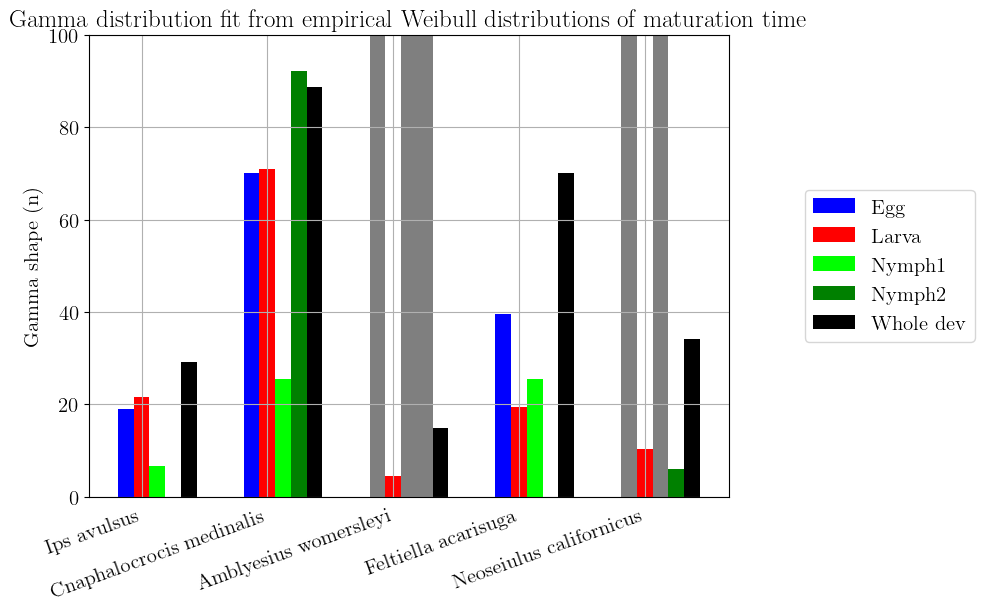

In [6]:
species = ("Ips avulsus", "Cnaphalocrocis medinalis", "Amblyesius womersleyi", "Feltiella acarisuga", "Neoseiulus californicus")
gamma_pars_dic = {
    'Egg': (19.00, 70.04, 0, 39.48, 0),
    'Larva': (21.63, 71.04, 4.47, 19.51, 10.38),
    'Nymph1': (6.58, 25.55, 0, 25.45, 0),
    'Nymph2': (0,92.27,0,0, 6.07),
    'Whole dev': (29.11, 88.74, 14.90, 70.14, 34.07)
}

gamma_pars_missing_values_dic = {
    'Egg': (0,0,100,0,100),
    'Larva': (0,0,0,0,0),
    'Nymph1': (0,0,100,0,100),
    'Nymph2': (0,0,100,0,0),
    'Whole dev': (0,0,0,0,0)
}


fig, ax = plt.subplots(layout='constrained', figsize = (9.6,6))
colors = ["blue", "red", "lime", "green", "black"]

x = 1.2*np.arange(len(species))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0
for attribute, measurement in gamma_pars_dic.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute, color = colors[int(multiplier)])
    # ax.bar_label(rects, padding=5)
    multiplier += 1


x = 1.2*np.arange(len(species))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0
for attribute, measurement in gamma_pars_missing_values_dic.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, color = "black", alpha = .5)
    # ax.bar_label(rects, padding=5)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Gamma shape (n)')
ax.set_xticks(x + width, species)
ax.set_ylim(0,100)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
plt.xticks(rotation=20, ha='right')
plt.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False)
plt.grid(True)
plt.savefig(FIG_DIR / "n_survey_example_species.pdf", bbox_inches = 'tight')
ax.set_title('Gamma distribution fit from empirical Weibull distributions of maturation time')
plt.show()
plt.close()